#### **모두를 위한 딥러닝**
slide
https://drive.google.com/drive/folders/1qVcF8-tx9LexdDT-IY6qOnHc8ekDoL03

git
https://github.com/deeplearningzerotoall/PyTorch?tab=readme-ov-file

youtube
https://www.youtube.com/watch?v=7eldOrjQVi0&list=PLQ28Nx3M4JrhkqBVIXg-i5_CVVoS1UzAv

```bash
docker run --gpus all -it --name pt -p 8888:8888 -p 8097:8097 deeplearningzerotoall/pytorch /bin/bash
```


---

### **ResNet**

- VGG-16이나 19는 층이 깊어질수록 오히려 학습이 안 되는 문제(Gradient Vanishing)가 발생하는데, ResNet은 이를 **Shortcut(Skip Connection)**로 해결함

In [1]:
import torch.nn as nn
import torch.utils.model_zoo as model_zoo


__all__ = ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101',
           'resnet152']


model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
}

In [2]:
def conv3x3(in_planes, out_planes, stride=1): # input channel, output channel(filter 개수)
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

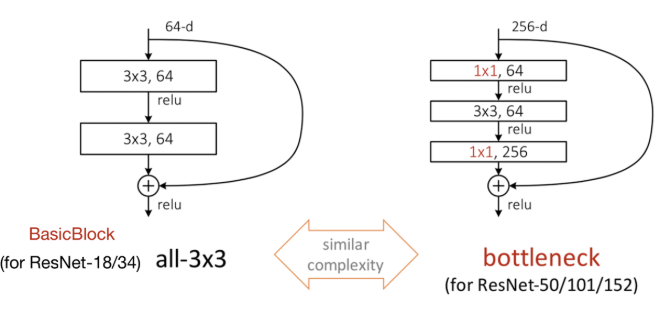

In [4]:
from IPython.display import Image, display
display(Image(filename='images/5.png', embed=True))

In [ ]:
#---- BasicBlock --------
# conv1->BN->ReLU -> Conv2->BN-> + inpux(x) [skip connection] -> ReLU
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample  # for downsampling
        self.stride = stride

    def forward(self, x):

        identity = x

        out = self.conv1(x) # 3x3 stride = 2
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out) # 3x3 stride = 1
        out = self.bn2(out)

        # conv1에서 stride=2를 써서 이미지 크기가 줄어들었다면, 위에 보관해둔 identity(=x)와
        # 현재 out의 모양이 달라서 더하기 불가 (따라서 크기와 채널수 맞춰주기)
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

#---- Bottleneck --------
# conv1->BN->ReLU -> Conv2->BN->ReLU -> Conv3->BN -> Skip connection
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = conv1x1(inplanes, planes) #conv1x1(64,64)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = conv3x3(planes, planes, stride)#conv3x3(64,64)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = conv1x1(planes, planes * self.expansion) #conv1x1(64,256)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        # 1x1으로 채널 줄이기
        out = self.conv1(x) # 1x1 stride = 1
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out) # 3x3 stride = stride 
        out = self.bn2(out)
        out = self.relu(out)

        # 1x1으로 채널 4배늘림
        out = self.conv3(out) # 1x1 stride = 1
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [6]:
class ResNet(nn.Module):
    # model = ResNet(Bottleneck, [3, 4, 6, 3], **kwargs) #resnet 50 
    def __init__(self, block, layers, num_classes=1000, zero_init_residual=False):
        super(ResNet, self).__init__()
        
        self.inplanes = 64 # 64 channel

        # RGB (input: 3 channel)
        # bias는 뒤에 BN이 오기때문에 필요없음
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True) # inplace: 덮어쓰기
        
        # 이미지 압축
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # 64채널 블럭 BasicBlock을 3층까지 이어붙임.
        self.layer1 = self._make_layer(block, 64, layers[0])
        # 128채널 블럭 4층
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        # BN을 0으로 만들면 out = Residual_Branch(x) + x, 결국 out = x가 됨. ( 아무런 층도 없는 효과 (gradient vanishing 발생 X))
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)
    
    def _make_layer(self, block, planes, blocks, stride=1):
        
        downsample = None
        
        # stride != 1 : image크기를 줄이는 경우
        # self.inplanes != planes * block.expensions : 들어오는 input꽈 Output 채널 수가 다른 경우
        if stride != 1 or self.inplanes != planes * block.expansion: 
            
            # downsample(채널 맞추기가 필요함)
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride), #conv1x1(256, 512, 2)
                nn.BatchNorm2d(planes * block.expansion), #batchnrom2d(512)
            )

        layers = []
        # layer 1~4 의미
        layers.append(block(self.inplanes, planes, stride, downsample))
        
        # 채널 늘어난 out을 다음 블록 입력에 맞추기 위해
        self.inplanes = planes * block.expansion #self.inplanes = 128 * 4
        
        for _ in range(1, blocks): 
            layers.append(block(self.inplanes, planes)) # * 3

        return nn.Sequential(*layers)
    

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

In [7]:
def resnet18(pretrained=False, **kwargs):
    model = ResNet(BasicBlock, [2, 2, 2, 2], **kwargs) #=> 2*(2+2+2+2) +1(conv1) +1(fc)  = 16 +2 =resnet 18
    return model
def resnet50(pretrained=False, **kwargs):
    model = ResNet(Bottleneck, [3, 4, 6, 3], **kwargs) #=> 3*(3+4+6+3) +(conv1) +1(fc) = 48 +2 = 50
    return model
def resnet152(pretrained=False, **kwargs):
    model = ResNet(Bottleneck, [3, 8, 36, 3], **kwargs) # 3*(3+8+36+3) +2 = 150+2 = resnet152    
    return model
import torchvision.models.resnet as resnet
res = resnet.resnet50()
res

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

---

### **Cifar10으로 ResNet 실습**

In [8]:
import torch
import torch.nn as nn

import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [10]:
import wandb

wandb.init(project="resnet-cifar10") 

def loss_tracker(loss_value, step):
    wandb.log({
        "train/loss": loss_value,
        "step": step
    })

# 예시: 학습 루프 안에서 사용 시
# loss_tracker(loss.item(), epoch)

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(777)
if device =='cuda':
    torch.cuda.manual_seed_all(777)
print(device)

cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./cifar10', train=True, download=True, transform=transform)

print(trainset.data.shape) # (50000, 32, 32, 3)

train_data_mean = trainset.data.mean( axis=(0,1,2) )
train_data_std = trainset.data.std( axis=(0,1,2) )


print(train_data_mean) # [125.30691805 122.95039414 113.86538318]
print(train_data_std)  # [62.99321928 62.08870764 66.70489964]

train_data_mean = train_data_mean / 255
train_data_std = train_data_std / 255

print(train_data_mean) # [0.49139968 0.48215841 0.44653091]
print(train_data_std) # [0.24703223 0.24348513 0.26158784]


(50000, 32, 32, 3)
[125.30691805 122.95039414 113.86538318]
[62.99321928 62.08870764 66.70489964]
[0.49139968 0.48215841 0.44653091]
[0.24703223 0.24348513 0.26158784]


In [15]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(train_data_mean, train_data_std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(train_data_mean, train_data_std)
])

trainset = torchvision.datasets.CIFAR10(root='./cifar10', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256,
                                          shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR10(root='./cifar10', train=False,
                                       download=True, transform=transform_test)

testloader = torch.utils.data.DataLoader(testset, batch_size=256,
                                         shuffle=False, num_workers=0)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [17]:
class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000, zero_init_residual=False):
        super(ResNet, self).__init__()
        self.inplanes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        #self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(block, 16, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 32, layers[1], stride=1)
        self.layer3 = self._make_layer(block, 64, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 128, layers[3], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        #x.shape =[1, 16, 32,32]
        x = self.bn1(x)
        x = self.relu(x)
        #x = self.maxpool(x)

        x = self.layer1(x)
        #x.shape =[1, 128, 32,32]
        x = self.layer2(x)
        #x.shape =[1, 256, 32,32]
        x = self.layer3(x)
        #x.shape =[1, 512, 16,16]
        x = self.layer4(x)
        #x.shape =[1, 1024, 8,8]
        
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

In [18]:
resnet50 = ResNet(resnet.Bottleneck, [3, 4, 6, 3], 10, True).to(device) 
#1(conv1) + 9(layer1) + 12(layer2) + 18(layer3) + 9(layer4) +1(fc)= ResNet50

resnet50

ResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_ru

In [19]:
a=torch.Tensor(1,3,32,32).to(device)
out = resnet50(a)
print(out)

tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


In [20]:
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.SGD(resnet50.parameters(), lr = 0.1, momentum = 0.9, weight_decay=5e-4)
lr_sche = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [22]:
def acc_check(net, test_set, epoch, save=1):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_set:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    acc = (100 * correct / total)
    print(f'Accuracy at epoch {epoch}: {acc}%')
    
    # [수정] 여기서 W&B에 정확도를 기록합니다.
    wandb.log({"test/accuracy": acc}, step=epoch)
    
    if save:
        torch.save(net.state_dict(), f"./model_epoch_{epoch}_acc_{int(acc)}.pth")
    return acc

In [ ]:
print(len(trainloader))
epochs = 150

for epoch in range(epochs):  # loop over the dataset multiple times

    running_loss = 0.0
    lr_sche.step()
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = resnet50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 30 == 29:    # print every 30 mini-batches
            avg_loss = running_loss / 30
            wandb.log({"train/loss": avg_loss}) 
            print(f'[{epoch + 1}, {i + 1}] loss: {avg_loss:.3f}')
            running_loss = 0.0
    
    #Check Accuracy
    acc = acc_check(resnet50, testloader, epoch, save=1)
    
    

print('Finished Training')

196
[1, 30] loss: 1.482
[1, 60] loss: 1.429
[1, 90] loss: 1.358
[1, 120] loss: 1.337
[1, 150] loss: 1.299
[1, 180] loss: 1.218
Accuracy at epoch 0: 50.99%


wandb: WARNING Tried to log to step 0 that is less than the current step 12. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


[2, 30] loss: 1.142
[2, 60] loss: 1.120
[2, 90] loss: 1.111
[2, 120] loss: 1.078
[2, 150] loss: 1.045
[2, 180] loss: 1.002
Accuracy at epoch 1: 58.73%


wandb: WARNING Tried to log to step 1 that is less than the current step 18. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


[3, 30] loss: 0.977
[3, 60] loss: 0.937
[3, 90] loss: 0.941
[3, 120] loss: 0.925
[3, 150] loss: 0.906
[3, 180] loss: 0.888
Accuracy at epoch 2: 63.48%


...

[17, 30] loss: 0.323
[17, 60] loss: 0.302
[17, 90] loss: 0.333
[17, 120] loss: 0.320
[17, 150] loss: 0.355
[17, 180] loss: 0.346
Accuracy at epoch 16: 81.42%


wandb: WARNING Tried to log to step 16 that is less than the current step 108. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


[18, 30] loss: 0.252
[18, 60] loss: 0.219
[18, 90] loss: 0.220
[18, 120] loss: 0.231
[18, 150] loss: 0.226
[18, 180] loss: 0.220
Accuracy at epoch 17: 84.49%


wandb: WARNING Tried to log to step 17 that is less than the current step 114. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


[19, 30] loss: 0.177
[19, 60] loss: 0.196
[19, 90] loss: 0.197
[19, 120] loss: 0.226
[19, 150] loss: 0.226
[19, 180] loss: 0.211
